In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)


In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
DATA_DIR = Path(r"C:/Users/rishe/Dissertation/data/gee_era5_data")
OUTPUT_DIR = Path(r"C:/Users/rishe/Dissertation/data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Column names
# ----------------------------
DATE_COL = "date"
STATION_COL = "station_id"
PRECIP_COL = "total_precipitation_sum"

# update these if your district mapping file uses different names
DISTRICT_META_PATH = Path(r"C:/Users/rishe/Dissertation/data/processed_rain_with_coords_final.parquet")

# ----------------------------
# Analysis switches
# ----------------------------
START_YEAR = 1970
END_YEAR = 2023

In [7]:
station_meta = pd.read_parquet(DISTRICT_META_PATH)

station_meta.columns = station_meta.columns.str.strip()

station_meta.head()

,station_id,date,year,month,day,day_of_year,rainfall,district,station_type,lat,lon
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,MURSHIDABAD,None,24.31,88.36
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,MURSHIDABAD,None,24.31,88.36
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,MURSHIDABAD,None,24.31,88.36
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,MURSHIDABAD,None,24.31,88.36
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,MURSHIDABAD,None,24.31,88.36


In [8]:
station_meta = station_meta.rename(columns={
    "lat": "latitude",
    "lon": "longitude",
})

station_meta[STATION_COL] = station_meta[STATION_COL].astype(str).str.strip()
station_meta["district"] = station_meta["district"].astype(str).str.strip()

In [9]:
station_meta.head()

,station_id,date,year,month,day,day_of_year,rainfall,district,station_type,latitude,longitude
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,MURSHIDABAD,None,24.31,88.36
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,MURSHIDABAD,None,24.31,88.36
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,MURSHIDABAD,None,24.31,88.36
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,MURSHIDABAD,None,24.31,88.36
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,MURSHIDABAD,None,24.31,88.36


In [10]:
files = sorted(DATA_DIR.glob("ERA5_Station_Data_*.csv"))
len(files), files[:3], files[-3:]

(54,
 [WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_1970.csv'),
  WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_1971.csv'),
  WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_1972.csv')],
 [WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_2021.csv'),
  WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_2022.csv'),
  WindowsPath('C:/Users/rishe/Dissertation/data/gee_era5_data/ERA5_Station_Data_2023.csv')])

In [11]:
year_pattern = re.compile(r"ERA5_Station_Data_(\d{4})\.csv")

def extract_year(path: Path) -> int:
    m = year_pattern.search(path.name)
    if not m:
        raise ValueError(f"Could not extract year from filename: {path.name}")
    return int(m.group(1))

dfs = []

for fp in files:
    year = extract_year(fp)
    if year < START_YEAR or year > END_YEAR:
        continue
    
    df_y = pd.read_csv(fp)
    df_y.columns = df_y.columns.str.strip()
    df_y["source_year"] = year
    dfs.append(df_y)

raw = pd.concat(dfs, ignore_index=True)
raw.head()

,date,station_id,total_precipitation_sum,temperature_2m,dewpoint_temperature_2m,surface_pressure,u_component_of_wind_10m,v_component_of_wind_10m,source_year
0,1970-01-01,AKRIGANJ,0.000001,290.550081,282.015345,101451.001139,1.429861,-1.679754,1970
1,1970-01-01,ALGARAH,0.000032,282.937939,279.363571,84739.084473,-0.110544,-0.104071,1970
2,1970-01-01,ALIPUR,0.000001,291.040071,281.454554,101608.751139,0.409028,-2.243149,1970
3,1970-01-01,ALIPURDUAR,0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159,1970
4,1970-01-01,ALIPURDUAR(CWC),0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159,1970


In [14]:
raw['source_year'].nunique()

54

In [18]:
raw.shape

(5739393, 9)

In [16]:
raw.columns.tolist()

['date',
 'station_id',
 'total_precipitation_sum',
 'temperature_2m',
 'dewpoint_temperature_2m',
 'surface_pressure',
 'u_component_of_wind_10m',
 'v_component_of_wind_10m',
 'source_year']

In [17]:
df = raw.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[STATION_COL] = df[STATION_COL].astype(str).str.strip()

# Drop rows with invalid date or station_id
df = df.dropna(subset=[DATE_COL, STATION_COL]).copy()

# Remove exact duplicates if any
df = df.drop_duplicates()

df.shape

(5739393, 9)

In [20]:
district_df = station_meta[["station_id", "district"]].drop_duplicates()
district_df.head()

,station_id,district
0,AKRIGANJ,MURSHIDABAD
17166,ALGARAH,DARJEELING
33237,ALIPUR,KOLKATA
77067,ALIPURDUAR,ALIPURDUAR
113227,ALIPURDUAR(CWC),ALIPURDUAR


In [21]:
district_df.shape

(293, 2)

In [22]:
df = df.merge(district_df, on=STATION_COL, how="left", validate="m:1")

df[[STATION_COL, "district"]].isna().sum()

station_id    0
district      0
dtype: int64

In [23]:
df.shape

(5739393, 10)

In [24]:
import gc
del raw
gc.collect()

1198

In [25]:
# precipitation: meters -> mm
df["precip_mm"] = pd.to_numeric(df[PRECIP_COL], errors="coerce") * 1000.0

# temperature: Kelvin -> Celsius
if "temperature_2m" in df.columns:
    df["temperature_2m_c"] = pd.to_numeric(df["temperature_2m"], errors="coerce") - 273.15

if "dewpoint_temperature_2m" in df.columns:
    df["dewpoint_temperature_2m_c"] = pd.to_numeric(df["dewpoint_temperature_2m"], errors="coerce") - 273.15

# pressure: Pa -> hPa
if "surface_pressure" in df.columns:
    df["surface_pressure_hpa"] = pd.to_numeric(df["surface_pressure"], errors="coerce") / 100.0

# wind speed from u/v components
if "u_component_of_wind_10m" in df.columns and "v_component_of_wind_10m" in df.columns:
    u = pd.to_numeric(df["u_component_of_wind_10m"], errors="coerce")
    v = pd.to_numeric(df["v_component_of_wind_10m"], errors="coerce")
    df["wind_speed_10m"] = np.sqrt(u**2 + v**2)

In [26]:
df["year"] = df[DATE_COL].dt.year
df["month"] = df[DATE_COL].dt.month
df["day"] = df[DATE_COL].dt.day
df["month_name"] = df[DATE_COL].dt.strftime("%b")
df["quarter"] = df[DATE_COL].dt.quarter
df["season"] = pd.cut(
    df["month"],
    bins=[0, 2, 5, 9, 12],
    labels=["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"],
    include_lowest=True
)

df.head()

,date,station_id,total_precipitation_sum,temperature_2m,dewpoint_temperature_2m,surface_pressure,u_component_of_wind_10m,v_component_of_wind_10m,source_year,district,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m,year,month,day,month_name,quarter,season
0,1970-01-01,AKRIGANJ,0.000001,290.550081,282.015345,101451.001139,1.429861,-1.679754,1970,MURSHIDABAD,0.001266,17.400081,8.865345,1014.510011,2.205919,1970,1,1,Jan,1,Winter
1,1970-01-01,ALGARAH,0.000032,282.937939,279.363571,84739.084473,-0.110544,-0.104071,1970,DARJEELING,0.032082,9.787939,6.213571,847.390845,0.151825,1970,1,1,Jan,1,Winter
2,1970-01-01,ALIPUR,0.000001,291.040071,281.454554,101608.751139,0.409028,-2.243149,1970,KOLKATA,0.001266,17.890071,8.304554,1016.087511,2.280137,1970,1,1,Jan,1,Winter
3,1970-01-01,ALIPURDUAR,0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159,1970,ALIPURDUAR,0.001266,16.945410,9.646432,1007.205011,0.728978,1970,1,1,Jan,1,Winter
4,1970-01-01,ALIPURDUAR(CWC),0.000001,290.095410,282.796432,100720.501139,-0.222605,-0.694159,1970,ALIPURDUAR,0.001266,16.945410,9.646432,1007.205011,0.728978,1970,1,1,Jan,1,Winter


In [27]:
missing_summary = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .to_frame("missing_frac")
)

missing_summary.head(20)

,missing_frac
date,0.0
temperature_2m_c,0.0
quarter,0.0
month_name,0.0
day,0.0
month,0.0
year,0.0
wind_speed_10m,0.0
surface_pressure_hpa,0.0
dewpoint_temperature_2m_c,0.0


In [28]:
station_coverage = (
    df.groupby(STATION_COL)
      .agg(
          n_obs=(DATE_COL, "size"),
          n_missing_precip=("precip_mm", lambda s: s.isna().sum()),
          min_date=(DATE_COL, "min"),
          max_date=(DATE_COL, "max"),
          district=("district", "first"),
      )
      .reset_index()
      .sort_values("n_obs", ascending=False)
)

station_coverage.head()

,station_id,n_obs,n_missing_precip,min_date,max_date,district
0,AKRIGANJ,19723,0,1970-01-01,2023-12-31,MURSHIDABAD
218,ONDA,19723,0,1970-01-01,2023-12-31,BANKURA
198,MO SALT LAKE,19723,0,1970-01-01,2023-12-31,24 PARGANAS N
197,MO KOLKATA,19723,0,1970-01-01,2023-12-31,24 PARGANAS N
196,MIDNAPORE(CWC),19723,0,1970-01-01,2023-12-31,PASCHIM MEDINIPUR


In [29]:
station_coverage.to_csv(OUTPUT_DIR / "station_coverage.csv", index=False)

In [30]:
district_coverage = (
    df.groupby("district")
      .agg(
          stations=(STATION_COL, "nunique"),
          n_obs=(DATE_COL, "size"),
          min_date=(DATE_COL, "min"),
          max_date=(DATE_COL, "max"),
      )
      .reset_index()
      .sort_values("stations", ascending=False)
)

district_coverage

,district,stations,n_obs,min_date,max_date
3,BANKURA,31,611413,1970-01-01,2023-12-31
20,PURBA MEDINIPUR,21,414183,1970-01-01,2023-12-31
21,PURULIA,19,374737,1970-01-01,2023-12-31
7,DARJEELING,19,374737,1970-01-01,2023-12-31
18,PASCHIM MEDINIPUR,19,374737,1970-01-01,2023-12-31
15,MURSHIDABAD,18,355014,1970-01-01,2023-12-31
4,BIRBHUM,16,315568,1970-01-01,2023-12-31
2,ALIPURDUAR,15,295845,1970-01-01,2023-12-31
8,HOOGLY,14,276122,1970-01-01,2023-12-31
10,JALPAIGURI,14,276122,1970-01-01,2023-12-31


In [31]:
# Default district aggregation: mean across stations at each district-date
district_daily = (
    df.groupby(["district", DATE_COL], as_index=False)
      .agg(
          precip_mm=("precip_mm", "mean"),
          temperature_2m_c=("temperature_2m_c", "mean"),
          dewpoint_temperature_2m_c=("dewpoint_temperature_2m_c", "mean"),
          surface_pressure_hpa=("surface_pressure_hpa", "mean"),
          wind_speed_10m=("wind_speed_10m", "mean"),
          year=("year", "first"),
          month=("month", "first"),
          quarter=("quarter", "first"),
      )
)

district_daily.head()

,district,date,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m,year,month,quarter
0,24 PARGANAS N,1970-01-01,0.001266,17.954915,8.872457,1016.096595,2.238933,1970,1,1
1,24 PARGANAS N,1970-01-02,0.000441,18.039395,8.857369,1015.530216,2.292602,1970,1,1
2,24 PARGANAS N,1970-01-03,0.000428,17.866589,9.261038,1013.854548,1.952403,1970,1,1
3,24 PARGANAS N,1970-01-04,0.000003,17.932919,9.803840,1013.267482,1.744910,1970,1,1
4,24 PARGANAS N,1970-01-05,0.000865,18.464906,9.944592,1014.723188,1.900871,1970,1,1


In [32]:
district_daily_sum = (
    df.groupby(["district", DATE_COL], as_index=False)
      .agg(
          precip_mm=("precip_mm", "sum"),
          temperature_2m_c=("temperature_2m_c", "mean"),
          dewpoint_temperature_2m_c=("dewpoint_temperature_2m_c", "mean"),
          surface_pressure_hpa=("surface_pressure_hpa", "mean"),
          wind_speed_10m=("wind_speed_10m", "mean"),
      )
)

In [33]:
district_daily_sum.head()

,district,date,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m
0,24 PARGANAS N,1970-01-01,0.012664,17.954915,8.872457,1016.096595,2.238933
1,24 PARGANAS N,1970-01-02,0.004411,18.039395,8.857369,1015.530216,2.292602
2,24 PARGANAS N,1970-01-03,0.004278,17.866589,9.261038,1013.854548,1.952403
3,24 PARGANAS N,1970-01-04,0.000032,17.932919,9.803840,1013.267482,1.744910
4,24 PARGANAS N,1970-01-05,0.008647,18.464906,9.944592,1014.723188,1.900871


In [34]:
monthly_district = (
    district_daily.assign(
        year=district_daily[DATE_COL].dt.year,
        month=district_daily[DATE_COL].dt.month,
        date_month=district_daily[DATE_COL].dt.to_period("M").dt.to_timestamp()
    )
    .groupby(["district", "date_month"], as_index=False)
    .agg(
        precip_mm=("precip_mm", "sum"),
        temperature_2m_c=("temperature_2m_c", "mean"),
        dewpoint_temperature_2m_c=("dewpoint_temperature_2m_c", "mean"),
        surface_pressure_hpa=("surface_pressure_hpa", "mean"),
        wind_speed_10m=("wind_speed_10m", "mean"),
    )
)

monthly_district["year"] = monthly_district["date_month"].dt.year
monthly_district["month"] = monthly_district["date_month"].dt.month

monthly_district.head()

,district,date_month,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m,year,month
0,24 PARGANAS N,1970-01-01,16.282039,19.304151,11.770539,1014.315018,1.474789,1970,1
1,24 PARGANAS N,1970-02-01,15.638376,22.807691,14.070688,1012.647719,1.421353,1970,2
2,24 PARGANAS N,1970-03-01,37.908761,27.138638,19.176148,1008.038749,2.134186,1970,3
3,24 PARGANAS N,1970-04-01,39.898846,30.214641,22.947907,1006.447564,3.167308,1970,4
4,24 PARGANAS N,1970-05-01,98.323054,30.673909,24.548693,1001.927419,3.193758,1970,5


In [35]:
monthly_counts = (
    monthly_district.groupby("district")
    .agg(
        n_months=("date_month", "size"),
        min_month=("date_month", "min"),
        max_month=("date_month", "max")
    )
    .reset_index()
)

monthly_counts

,district,n_months,min_month,max_month
0,24 PARGANAS N,648,1970-01-01,2023-12-01
1,24 PARGANAS S,648,1970-01-01,2023-12-01
2,ALIPURDUAR,648,1970-01-01,2023-12-01
3,BANKURA,648,1970-01-01,2023-12-01
4,BIRBHUM,648,1970-01-01,2023-12-01
5,COOCH BEHAR,648,1970-01-01,2023-12-01
6,DAKSHIN DINAJPUR,648,1970-01-01,2023-12-01
7,DARJEELING,648,1970-01-01,2023-12-01
8,HOOGLY,648,1970-01-01,2023-12-01
9,HOWRAH,648,1970-01-01,2023-12-01


In [36]:
expected_months = (END_YEAR - START_YEAR + 1) * 12
expected_months

648

In [37]:
baseline_period = (1971, 2000)   # can change later

baseline = monthly_district[
    (monthly_district["year"] >= baseline_period[0]) &
    (monthly_district["year"] <= baseline_period[1])
].copy()

district_monthly_climatology = (
    baseline.groupby(["district", "month"], as_index=False)
            .agg(
                precip_clim_mm=("precip_mm", "mean"),
                precip_clim_std=("precip_mm", "std"),
            )
)

district_monthly_climatology.head()

,district,month,precip_clim_mm,precip_clim_std
0,24 PARGANAS N,1,9.440261,11.331825
1,24 PARGANAS N,2,28.497404,24.077729
2,24 PARGANAS N,3,37.025899,45.091177
3,24 PARGANAS N,4,88.544910,68.087827
4,24 PARGANAS N,5,157.324393,78.329628


In [38]:
df.to_parquet(OUTPUT_DIR / "era5_station_level_clean.parquet", index=False)
district_daily.to_parquet(OUTPUT_DIR / "era5_district_daily_mean.parquet", index=False)
monthly_district.to_parquet(OUTPUT_DIR / "era5_monthly_district.parquet", index=False)

district_coverage.to_csv(OUTPUT_DIR / "district_coverage.csv", index=False)
station_coverage.to_csv(OUTPUT_DIR / "station_coverage.csv", index=False)

In [39]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
})

data_dictionary.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)
data_dictionary.head(30)

,column,dtype
0,date,datetime64[ns]
1,station_id,object
2,total_precipitation_sum,float64
3,temperature_2m,float64
4,dewpoint_temperature_2m,float64
5,surface_pressure,float64
6,u_component_of_wind_10m,float64
7,v_component_of_wind_10m,float64
8,source_year,int64
9,district,object


In [40]:
district_df.to_csv(OUTPUT_DIR / "district_mapping.csv", index=False)

In [44]:
district_df['district'].unique()

array(['MURSHIDABAD', 'DARJEELING', 'KOLKATA', 'ALIPURDUAR', 'PURULIA',
       'BANKURA', 'PASCHIM MEDINIPUR', 'HOWRAH', 'HOOGLY',
       'PASCHIM BARDHAMAN', 'KALIMPONG', 'DAKSHIN DINAJPUR', 'MALDA',
       '24 PARGANAS N', '24 PARGANAS S', 'BIRBHUM', 'PURBA BARDHAMAN',
       'NADIA', 'PURBA MEDINIPUR', 'JALPAIGURI', 'UTTAR DINAJPUR',
       'COOCH BEHAR', 'JHARGRAM'], dtype=object)

In [42]:
gdf['NAME']

0               Jhargram
1              Kalimpong
2                Kolkata
3     Paschim Barddhaman
4     Pashchim Medinipur
5             Alipurduar
6                Bankura
7                Birbhum
8       Dakshin Dinajpur
9                  Haora
10                 Hugli
11            Jalpaiguri
12            Koch Bihar
13               Kolkata
14                Maldah
15           Murshidabad
16                 Nadia
17     North 24 Parganas
18       Purba Medinipur
19              Puruliya
20     South 24 Parganas
21        Uttar Dinajpur
22             Darjiling
23      Purba Barddhaman
Name: NAME, dtype: object

In [41]:
import geopandas as gpd

shapefile_path = r"C:/Users/rishe/Dissertation/data/West_Bengal/District_shape_West_Bengal.shp"

gdf = gpd.read_file(shapefile_path)

print(gdf.columns)
gdf.head()

Index(['GM_LAYER', 'NAME', 'NAME_0', 'NAME_1', 'geometry'], dtype='object')


GM_LAYER                NAME NAME_0       NAME_1  \
0  Unknown Area Type            Jhargram  India  West Bengal   
1  Unknown Area Type           Kalimpong  India  West Bengal   
2  Unknown Area Type             Kolkata  India  West Bengal   
3  Unknown Area Type  Paschim Barddhaman  India  West Bengal   
4  Unknown Area Type  Pashchim Medinipur  India  West Bengal   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [45]:
import pandas as pd
import geopandas as gpd

# ----- canonical display names -----
canonical_map = {
    "DARJEELING": "Darjeeling",
    "Darjiling": "Darjeeling",

    "HOOGHLY": "Hooghly",
    "Hugli": "Hooghly",

    "HOWRAH": "Howrah",
    "Haora": "Howrah",

    "COOCH BEHAR": "Cooch Behar",
    "Koch Bihar": "Cooch Behar",

    "PURULIA": "Purulia",
    "Puruliya": "Purulia",

    "MALDA": "Maldah",
    "Maldah": "Maldah",

    "24 PARGANAS N": "North 24 Parganas",
    "North 24 Parganas": "North 24 Parganas",

    "24 PARGANAS S": "South 24 Parganas",
    "South 24 Parganas": "South 24 Parganas",

    "PASCHIM MEDINIPUR": "Paschim Medinipur",
    "Paschim Medinipur": "Paschim Medinipur",

    "PURBA MEDINIPUR": "Purba Medinipur",
    "Purba Medinipur": "Purba Medinipur",

    "PASCHIM BARDHAMAN": "Paschim Bardhaman",
    "Paschim Barddhaman": "Paschim Bardhaman",

    "PURBA BARDHAMAN": "Purba Bardhaman",
    "Purba Barddhaman": "Purba Bardhaman",

    "JALPAIGURI": "Jalpaiguri",
    "Jalpaiguri": "Jalpaiguri",

    "BANKURA": "Bankura",
    "Bankura": "Bankura",

    "BIRBHUM": "Birbhum",
    "Birbhum": "Birbhum",

    "NADIA": "Nadia",
    "Nadia": "Nadia",

    "MURSHIDABAD": "Murshidabad",
    "Murshidabad": "Murshidabad",

    "KOLKATA": "Kolkata",
    "Kolkata": "Kolkata",

    "ALIPURDUAR": "Alipurduar",
    "Alipurduar": "Alipurduar",

    "KALIMPONG": "Kalimpong",
    "Kalimpong": "Kalimpong",

    "JHARGRAM": "Jhargram",
    "Jhargram": "Jhargram",

    "DINAJPUR SOUTH": "Dakshin Dinajpur",
    "Dakshin Dinajpur": "Dakshin Dinajpur",

    "DINAJPUR NORTH": "Uttar Dinajpur",
    "Uttar Dinajpur": "Uttar Dinajpur",
}

In [46]:
def normalize_text(x):
    return str(x).strip()

district_df["district_std"] = district_df["district"].map(normalize_text).map(canonical_map).fillna(district_df["district"])
gdf["district_std"] = gdf["NAME"].map(normalize_text).map(canonical_map).fillna(gdf["NAME"])

district_df["district_std"] = district_df["district_std"].astype(str)
gdf["district_std"] = gdf["district_std"].astype(str)

district_df["district_std"].unique(), gdf["district_std"].unique()

(array(['Murshidabad', 'Darjeeling', 'Kolkata', 'Alipurduar', 'Purulia',
        'Bankura', 'Paschim Medinipur', 'Howrah', 'HOOGLY',
        'Paschim Bardhaman', 'Kalimpong', 'DAKSHIN DINAJPUR', 'Maldah',
        'North 24 Parganas', 'South 24 Parganas', 'Birbhum',
        'Purba Bardhaman', 'Nadia', 'Purba Medinipur', 'Jalpaiguri',
        'UTTAR DINAJPUR', 'Cooch Behar', 'Jhargram'], dtype=object),
 array(['Jhargram', 'Kalimpong', 'Kolkata', 'Paschim Bardhaman',
        'Pashchim Medinipur', 'Alipurduar', 'Bankura', 'Birbhum',
        'Dakshin Dinajpur', 'Howrah', 'Hooghly', 'Jalpaiguri',
        'Cooch Behar', 'Maldah', 'Murshidabad', 'Nadia',
        'North 24 Parganas', 'Purba Medinipur', 'Purulia',
        'South 24 Parganas', 'Uttar Dinajpur', 'Darjeeling',
        'Purba Bardhaman'], dtype=object))

In [48]:
# Check for unmapped names (where canonical_map didn't apply, so fillna used the original)
unmapped_district_df = district_df[district_df["district_std"] == district_df["district"]]["district"].unique()
unmapped_gdf = gdf[gdf["district_std"] == gdf["NAME"]]["NAME"].unique()

print("Unmapped in district_df:", unmapped_district_df)
print("Unmapped in gdf:", unmapped_gdf)

# Get unique standardized names
district_std_unique = set(district_df["district_std"].unique())
gdf_std_unique = set(gdf["district_std"].unique())

print("Unique district_std in district_df:", sorted(district_std_unique))
print("Unique district_std in gdf:", sorted(gdf_std_unique))

# Check for exact match
if district_std_unique == gdf_std_unique:
    print("✅ All district names are correctly mapped and match between district_df and gdf.")
else:
    # Find differences
    only_in_district_df = district_std_unique - gdf_std_unique
    only_in_gdf = gdf_std_unique - district_std_unique
    print("❌ Mismatches found:")
    print("  - Only in district_df:", sorted(only_in_district_df))
    print("  - Only in gdf:", sorted(only_in_gdf))

Unmapped in district_df: ['HOOGLY' 'DAKSHIN DINAJPUR' 'UTTAR DINAJPUR']
Unmapped in gdf: ['Jhargram' 'Kalimpong' 'Kolkata' 'Pashchim Medinipur' 'Alipurduar'
 'Bankura' 'Birbhum' 'Dakshin Dinajpur' 'Jalpaiguri' 'Maldah'
 'Murshidabad' 'Nadia' 'North 24 Parganas' 'Purba Medinipur'
 'South 24 Parganas' 'Uttar Dinajpur']
Unique district_std in district_df: ['Alipurduar', 'Bankura', 'Birbhum', 'Cooch Behar', 'DAKSHIN DINAJPUR', 'Darjeeling', 'HOOGLY', 'Howrah', 'Jalpaiguri', 'Jhargram', 'Kalimpong', 'Kolkata', 'Maldah', 'Murshidabad', 'Nadia', 'North 24 Parganas', 'Paschim Bardhaman', 'Paschim Medinipur', 'Purba Bardhaman', 'Purba Medinipur', 'Purulia', 'South 24 Parganas', 'UTTAR DINAJPUR']
Unique district_std in gdf: ['Alipurduar', 'Bankura', 'Birbhum', 'Cooch Behar', 'Dakshin Dinajpur', 'Darjeeling', 'Hooghly', 'Howrah', 'Jalpaiguri', 'Jhargram', 'Kalimpong', 'Kolkata', 'Maldah', 'Murshidabad', 'Nadia', 'North 24 Parganas', 'Paschim Bardhaman', 'Pashchim Medinipur', 'Purba Bardhaman', 'P

In [47]:
data_names = set(district_df["district_std"].unique())
shape_names = set(gdf["district_std"].unique())

print("In data but not shapefile:", sorted(data_names - shape_names))
print("In shapefile but not data:", sorted(shape_names - data_names))

In data but not shapefile: ['DAKSHIN DINAJPUR', 'HOOGLY', 'Paschim Medinipur', 'UTTAR DINAJPUR']
In shapefile but not data: ['Dakshin Dinajpur', 'Hooghly', 'Pashchim Medinipur', 'Uttar Dinajpur']


In [49]:
# Updated canonical_map with missing keys (added based on unmapped names and mismatches)
canonical_map = {
    "DARJEELING": "Darjeeling",
    "Darjiling": "Darjeeling",

    "HOOGHLY": "Hooghly",
    "HOOGLY": "Hooghly",  # Added for data spelling
    "Hugli": "Hooghly",

    "HOWRAH": "Howrah",
    "Haora": "Howrah",

    "COOCH BEHAR": "Cooch Behar",
    "Koch Bihar": "Cooch Behar",

    "PURULIA": "Purulia",
    "Puruliya": "Purulia",

    "MALDA": "Maldah",
    "Maldah": "Maldah",

    "24 PARGANAS N": "North 24 Parganas",
    "North 24 Parganas": "North 24 Parganas",

    "24 PARGANAS S": "South 24 Parganas",
    "South 24 Parganas": "South 24 Parganas",

    "PASCHIM MEDINIPUR": "Paschim Medinipur",
    "Paschim Medinipur": "Paschim Medinipur",
    "Pashchim Medinipur": "Paschim Medinipur",  # Added for shapefile spelling

    "PURBA MEDINIPUR": "Purba Medinipur",
    "Purba Medinipur": "Purba Medinipur",

    "PASCHIM BARDHAMAN": "Paschim Bardhaman",
    "Paschim Barddhaman": "Paschim Bardhaman",

    "PURBA BARDHAMAN": "Purba Bardhaman",
    "Purba Barddhaman": "Purba Bardhaman",

    "JALPAIGURI": "Jalpaiguri",
    "Jalpaiguri": "Jalpaiguri",

    "BANKURA": "Bankura",
    "Bankura": "Bankura",

    "BIRBHUM": "Birbhum",
    "Birbhum": "Birbhum",

    "NADIA": "Nadia",
    "Nadia": "Nadia",

    "MURSHIDABAD": "Murshidabad",
    "Murshidabad": "Murshidabad",

    "KOLKATA": "Kolkata",
    "Kolkata": "Kolkata",

    "ALIPURDUAR": "Alipurduar",
    "Alipurduar": "Alipurduar",

    "KALIMPONG": "Kalimpong",
    "Kalimpong": "Kalimpong",

    "JHARGRAM": "Jhargram",
    "Jhargram": "Jhargram",

    "DINAJPUR SOUTH": "Dakshin Dinajpur",
    "DAKSHIN DINAJPUR": "Dakshin Dinajpur",  # Added for data spelling
    "Dakshin Dinajpur": "Dakshin Dinajpur",

    "DINAJPUR NORTH": "Uttar Dinajpur",
    "UTTAR DINAJPUR": "Uttar Dinajpur",  # Added for data spelling
    "Uttar Dinajpur": "Uttar Dinajpur",
}

# Re-apply mapping
def normalize_text(x):
    return str(x).strip()

district_df["district_std"] = district_df["district"].map(normalize_text).map(canonical_map).fillna(district_df["district"])
gdf["district_std"] = gdf["NAME"].map(normalize_text).map(canonical_map).fillna(gdf["NAME"])

district_df["district_std"] = district_df["district_std"].astype(str)
gdf["district_std"] = gdf["district_std"].astype(str)

# Corrected unmapped check: names not in canonical_map.keys()
unmapped_district_df = district_df[~district_df["district"].isin(canonical_map.keys())]["district"].unique()
unmapped_gdf = gdf[~gdf["NAME"].isin(canonical_map.keys())]["NAME"].unique()

print("Unmapped in district_df:", unmapped_district_df)
print("Unmapped in gdf:", unmapped_gdf)

# Unique standardized names
district_std_unique = set(district_df["district_std"].unique())
gdf_std_unique = set(gdf["district_std"].unique())

print("Unique district_std in district_df:", sorted(district_std_unique))
print("Unique district_std in gdf:", sorted(gdf_std_unique))

# Check for exact match
if district_std_unique == gdf_std_unique:
    print("✅ All district names are correctly mapped and match between district_df and gdf.")
else:
    only_in_district_df = district_std_unique - gdf_std_unique
    only_in_gdf = gdf_std_unique - district_std_unique
    print("❌ Mismatches found:")
    print("  - Only in district_df:", sorted(only_in_district_df))
    print("  - Only in gdf:", sorted(only_in_gdf))

Unmapped in district_df: []
Unmapped in gdf: []
Unique district_std in district_df: ['Alipurduar', 'Bankura', 'Birbhum', 'Cooch Behar', 'Dakshin Dinajpur', 'Darjeeling', 'Hooghly', 'Howrah', 'Jalpaiguri', 'Jhargram', 'Kalimpong', 'Kolkata', 'Maldah', 'Murshidabad', 'Nadia', 'North 24 Parganas', 'Paschim Bardhaman', 'Paschim Medinipur', 'Purba Bardhaman', 'Purba Medinipur', 'Purulia', 'South 24 Parganas', 'Uttar Dinajpur']
Unique district_std in gdf: ['Alipurduar', 'Bankura', 'Birbhum', 'Cooch Behar', 'Dakshin Dinajpur', 'Darjeeling', 'Hooghly', 'Howrah', 'Jalpaiguri', 'Jhargram', 'Kalimpong', 'Kolkata', 'Maldah', 'Murshidabad', 'Nadia', 'North 24 Parganas', 'Paschim Bardhaman', 'Paschim Medinipur', 'Purba Bardhaman', 'Purba Medinipur', 'Purulia', 'South 24 Parganas', 'Uttar Dinajpur']
✅ All district names are correctly mapped and match between district_df and gdf.


In [50]:
data_names = set(district_df["district_std"].unique())
shape_names = set(gdf["district_std"].unique())

print("In data but not shapefile:", sorted(data_names - shape_names))
print("In shapefile but not data:", sorted(shape_names - data_names))

In data but not shapefile: []
In shapefile but not data: []


In [51]:
gdf[gdf["district_std"].str.contains("Kolkata", case=False, na=False)]

,GM_LAYER,NAME,NAME_0,NAME_1,geometry,district_std
2,Unknown Area Type,Kolkata,India,West Bengal,"POLYGON ((88.40731 22.55647, 88.4057 22.55393, 88.39901 22.55484, 88.39803 22.5538, 88.39852 22.54905, 88.39169 22.54053, 88.38725 22.53896, 88.38708 22.53387, 88.37975 22.52355, 88.37599 22.52135, 88.37157 22.5229, 88.36964 22.51531, 88.36966 22.50751, 88.36771 22.50051, 88.36444 22.49522, 88.35895 22.49494, 88.35246 22.49553, 88.3467 22.49495, 88.33617 22.4978, 88.32837 22.50368, 88.32434 22.50546, 88.32058 22.50474, 88.31216 22.50594, 88.29748 22.51079, 88.29389 22.51119, 88.28808 22.51406, 88.28793 22.52516, 88.28644 22.53262, 88.28159 22.54314, 88.27466 22.54362, 88.27193 22.54599, 88.27065 22.55176, 88.2836 22.54805, 88.30818 22.54461, 88.32072 22.54685, 88.32889 22.55214, 88.34345 22.57352, 88.34811 22.58893, 88.35233 22.59674, 88.35979 22.60602, 88.3645 22.60494, 88.36552 22.61235, 88.36414 22.62066, 88.35968 22.62974, 88.38059 22.62777, 88.38863 22.62635, 88.39062 22.62474, 88.39211 22.61843, 88.39306 22.59774, 88.3919 22.59079, 88.39434 22.58334, 88.40217 22.56971, 88.40376 22.56231, 88.40731 22.55647))",Kolkata
13,Unknown Area Type,Kolkata,India,West Bengal,"POLYGON ((88.40731 22.55647, 88.4057 22.55393, 88.39901 22.55484, 88.39803 22.5538, 88.39852 22.54905, 88.39169 22.54053, 88.38725 22.53896, 88.38708 22.53387, 88.37975 22.52355, 88.37599 22.52135, 88.37157 22.5229, 88.36964 22.51531, 88.36966 22.50751, 88.36771 22.50051, 88.36444 22.49522, 88.35895 22.49494, 88.35246 22.49553, 88.3467 22.49495, 88.33617 22.4978, 88.32837 22.50368, 88.32434 22.50546, 88.32058 22.50474, 88.31216 22.50594, 88.29748 22.51079, 88.29389 22.51119, 88.28808 22.51406, 88.28793 22.52516, 88.28644 22.53262, 88.28159 22.54314, 88.27466 22.54362, 88.27193 22.54599, 88.27065 22.55176, 88.2836 22.54805, 88.30818 22.54461, 88.32072 22.54685, 88.32889 22.55214, 88.34345 22.57352, 88.34811 22.58893, 88.35233 22.59674, 88.35979 22.60602, 88.3645 22.60494, 88.36552 22.61235, 88.36414 22.62066, 88.35968 22.62974, 88.38059 22.62777, 88.38863 22.62635, 88.39062 22.62474, 88.39211 22.61843, 88.39306 22.59774, 88.3919 22.59079, 88.39434 22.58334, 88.40217 22.56971, 88.40376 22.56231, 88.40731 22.55647))",Kolkata


In [52]:
gdf = gdf.dissolve(by="district_std", as_index=False)

In [53]:
district_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 4718655
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   station_id    293 non-null    object
 1   district      293 non-null    object
 2   district_std  293 non-null    object
dtypes: object(3)
memory usage: 9.2+ KB


In [54]:
district_daily.head()

,district,date,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m,year,month,quarter
0,24 PARGANAS N,1970-01-01,0.001266,17.954915,8.872457,1016.096595,2.238933,1970,1,1
1,24 PARGANAS N,1970-01-02,0.000441,18.039395,8.857369,1015.530216,2.292602,1970,1,1
2,24 PARGANAS N,1970-01-03,0.000428,17.866589,9.261038,1013.854548,1.952403,1970,1,1
3,24 PARGANAS N,1970-01-04,0.000003,17.932919,9.803840,1013.267482,1.744910,1970,1,1
4,24 PARGANAS N,1970-01-05,0.000865,18.464906,9.944592,1014.723188,1.900871,1970,1,1


In [55]:
district_daily["district_std"] = district_daily["district"].map(normalize_text).map(canonical_map).fillna(district_df["district"])


In [56]:
district_mean = (
    district_daily.groupby("district_std", as_index=False)
    .agg(avg_precip_mm=("precip_mm", "mean"))
)

map_df = gdf.merge(district_mean, on="district_std", how="left")

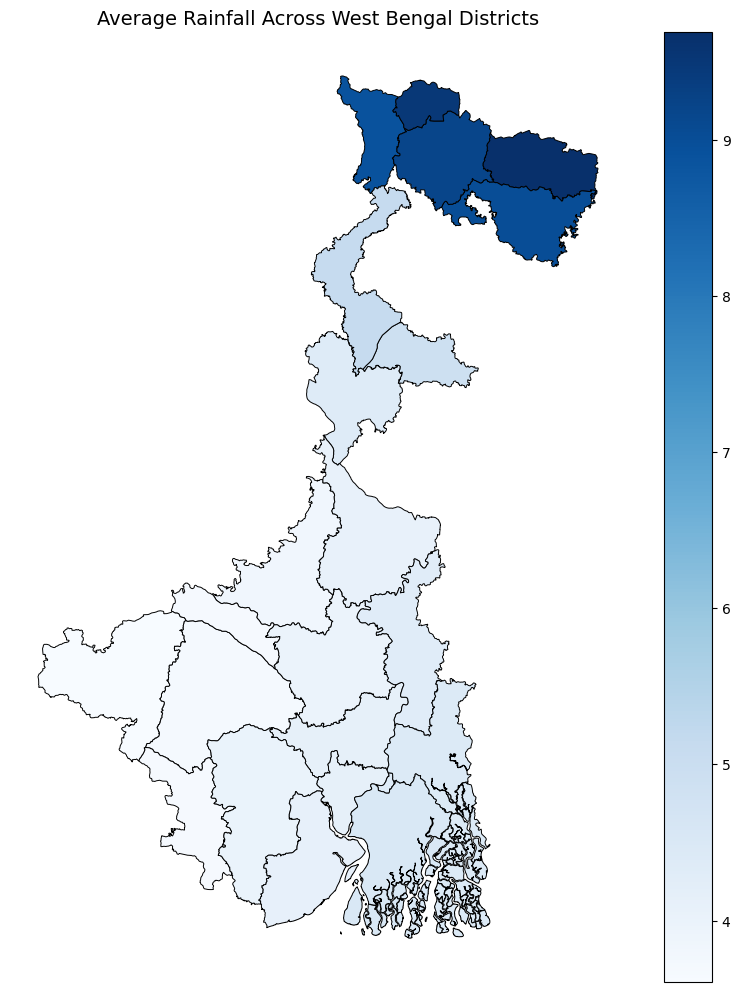

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

map_df.plot(
    column="avg_precip_mm",
    cmap="Blues",
    legend=True,
    linewidth=0.7,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

ax.set_title("Average Rainfall Across West Bengal Districts", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()